# Imports

In [3]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



In [3]:
def drop_unperturb_trials_modified(td_tr_, dstrb_idx, thresh_val = -2.5):
    td_tr = td_tr_.copy()
    disturb_mean_vals_s = td_tr['disturb_mean'].values

    threshold_s = -scipy.stats.sem(disturb_mean_vals_s)
    disturb_mean_sorted_s = disturb_mean_vals_s[dstrb_idx]
    idx_to_keep_s = int(np.searchsorted(disturb_mean_sorted_s, threshold_s))

    # Original selected trials
    selected_by_threshold = np.zeros(len(td_tr), dtype=bool)
    selected_by_threshold[dstrb_idx[:idx_to_keep_s]] = True

    # Additional trials with disturb_mean > -2
    selected_by_value = disturb_mean_vals_s > thresh_val

    # Keep trials satisfying either condition
    final_mask = selected_by_threshold & selected_by_value

    print(
        f"  threshold = {threshold_s:.3f}  |  "
        f"trials selected by threshold: {idx_to_keep_s}  |  "
        f"total trials kept: {final_mask.sum()}"
    )

    td_tr = td_tr.iloc[np.where(final_mask)[0]]
    return td_tr

In [5]:
def drop_unperturb_trials(td_tr_, dstrb_idx):
    td_tr = td_tr_.copy()
    disturb_mean_vals_s = td_tr['disturb_mean'].values
    threshold_s = -scipy.stats.sem(disturb_mean_vals_s)
    disturb_mean_sorted_s = disturb_mean_vals_s[dstrb_idx]
    idx_to_keep_s = int(np.searchsorted(disturb_mean_sorted_s, threshold_s))

    print(f"  threshold = {threshold_s:.3f}  |  trials selected: {idx_to_keep_s}")
    td_tr = td_tr.iloc[sorted(dstrb_idx[:idx_to_keep_s])]
    return td_tr

# Load session

In [7]:
session = 'M061_2025_03_06_14_00'
data_dir='/data/bnd-data/raw/'


In [5]:
df_tr, dstrb_idx = dsp.load_and_process_session(session, data_dir)


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).


In [6]:
disturb_mean_vals_s = df_tr["disturb_mean"].values
threshold_s = -scipy.stats.sem(disturb_mean_vals_s)
disturb_mean_sorted_s = disturb_mean_vals_s[dstrb_idx]
idx_to_keep_s = int(np.searchsorted(disturb_mean_sorted_s, threshold_s))
print(f"  threshold = {threshold_s:.3f}  |  trials selected: {idx_to_keep_s}")

df_design_s = df_tr.iloc[sorted(dstrb_idx[:idx_to_keep_s])]
perturb_td_s = pyal.restrict_to_interval(
    df_design_s, start_point_name="idx_sol_on", rel_start=-200, rel_end=350
)
perturb_td_s = dt.add_bhv(perturb_td_s)
perturb_td_shuff = perturb_td_s.sample(frac=1, random_state=42).reset_index(drop=False)

  threshold = -0.031  |  trials selected: 220


In [7]:


signal_x   = 'MOp_rates_pca'
signal_y   = 'CP_rates_pca'
target_rank = 30
origin_rank = 30

r2, opt_rank = subspaces.windowed_cross_val_semedo_rrr_td(
    perturb_td_shuff,
    signal_x,
    signal_y,
    target_rank,
    window=(0, 180),
    fit_rank=True,
    rank=target_rank,
    origin_rank=origin_rank
)

print(f"MOp → CP  |  opt_rank = {opt_rank}  |  R² = {r2.mean():.3f} ± {r2.std():.3f}")


MOp → CP  |  opt_rank = 6  |  R² = 0.146 ± 0.012


In [71]:
lags = np.arange(-10, 12, step=2)
lags

array([-10,  -8,  -6,  -4,  -2,   0,   2,   4,   6,   8,  10])

In [8]:
AREAS = ['MOp', 'SSp', 'CP', 'VAL']
WINDOWS = {'pre': (10, 190), 'perturb': (200, 380)}

rank_dict = {
    'MOp': 30,
    'CP': 30,
    'VAL': 50,
    'SSp': 10
}
lags = np.arange(-20, 21, step=1)
# results[window_label][src][tgt] = (r2_mean, r2_std)
results = {label: {} for label in WINDOWS}

for label, window in WINDOWS.items():
    print(f"\n{'='*60}\nWindow: {label} {window}\n{'='*60}")
    for lag in tqdm(lags):
        results[label][lag] = {}

        for src in AREAS:
            results[label][lag][src] = {}
            for tgt in AREAS:
                if src == tgt:
                    results[label][lag][src][tgt] = (np.nan, np.nan)
                    continue
                sig_x = f'{src}_rates_pca'
                sig_y = f'{tgt}_rates_pca'
                if sig_x not in perturb_td_shuff.columns or sig_y not in perturb_td_shuff.columns:
                    print(f"  {src} → {tgt}: missing column, skipping")
                    results[label][lag][src][tgt] = (np.nan, np.nan)
                    continue
                r2, opt_rank = subspaces.windowed_cross_val_semedo_rrr_td(
                    perturb_td_shuff, sig_x, sig_y,
                    target_rank=rank_dict[tgt],
                    window=window,
                    fit_rank=True,
                    origin_rank=rank_dict[src],
                    lag = lag
                )
                results[label][lag][src][tgt] = r2
                # print(f"  {src} → {tgt}  opt_rank={opt_rank}  R²={r2.mean():.3f} ± {r2.std():.3f}")





Window: pre (10, 190)


  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [06:18<00:00,  9.22s/it]



Window: perturb (200, 380)


100%|██████████| 41/41 [06:16<00:00,  9.18s/it]


In [ ]:
fig, ax = plt.subplots()


KeyError: 'MOp'

KeyError: 'MOp'

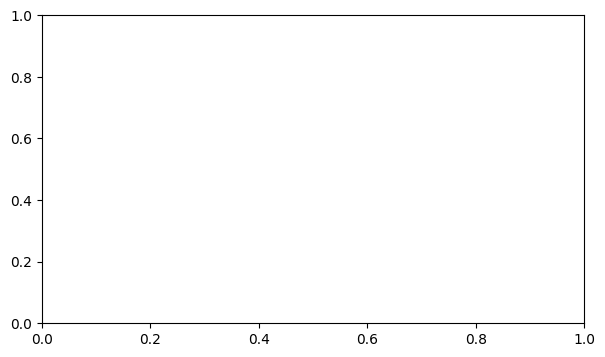

In [52]:
# --- Dots + errorbars: one panel per window, one dot per src→tgt pair ---
pairs = [(src, tgt) for src in AREAS for tgt in AREAS if src != tgt]
pair_labels = [f'{src}→{tgt}' for src, tgt in pairs]
x_pos = np.arange(len(pairs))

window_colors = {'pre': 'steelblue', 'perturb': 'tomato'}
offset = {'pre': -0.15, 'perturb': 0.15}

fig, ax = plt.subplots(figsize=(7, 4))  # smaller figure for better label readability

for label in WINDOWS:
    c = window_colors[label]
    for i, (src, tgt) in enumerate(pairs):
        mean, std = results[label][src][tgt]
        if np.isnan(mean):
            continue
        ax.errorbar(i + offset[label], mean, yerr=std,
                    fmt='o', color=c, capsize=3, capthick=1.2, ms=6, zorder=3)

# legend proxies
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color=window_colors[l], linestyle='',
                  ms=7, label=f'{l} {WINDOWS[l]}') for l in WINDOWS]
ax.legend(handles=handles, frameon=False)

ax.axhline(0, color='k', lw=0.6, linestyle='--')
ax.set_xticks(x_pos)
ax.set_xticklabels(pair_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² (mean ± std across folds)')
ax.set_title('RRR R²: source → target')
plt.tight_layout()
plt.show()


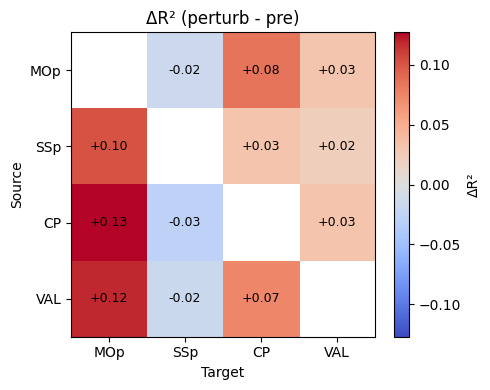

In [51]:
# --- Heatmap of R² difference (perturb - pre) ---
diff_mat = np.full((len(AREAS), len(AREAS)), np.nan)
for i, src in enumerate(AREAS):
    for j, tgt in enumerate(AREAS):
        if src == tgt:
            continue
        pre = results['pre'][src][tgt][0]
        post = results['perturb'][src][tgt][0]
        if not np.isnan(pre) and not np.isnan(post):
            diff_mat[i, j] = post - pre

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(diff_mat, cmap='coolwarm', vmin=-np.nanmax(np.abs(diff_mat)), vmax=np.nanmax(np.abs(diff_mat)), aspect='auto')
ax.set_xticks(range(len(AREAS)))
ax.set_xticklabels(AREAS)
ax.set_yticks(range(len(AREAS)))
ax.set_yticklabels(AREAS)
ax.set_xlabel('Target')
ax.set_ylabel('Source')
ax.set_title('ΔR² (perturb - pre)')
for i in range(len(AREAS)):
    for j in range(len(AREAS)):
        val = diff_mat[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center', color='black', fontsize=9)
plt.colorbar(im, ax=ax, label='ΔR²')
plt.tight_layout()
plt.show()


In [76]:
[results['pre'][lag]['MOp']['CP'] for lag in lags]

[array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186]),
 array([0.13534001, 0.15499526, 0.16309604, 0.14741957, 0.12917186])]

In [74]:
results['pre'][lag][src][tgt]

(nan, nan)

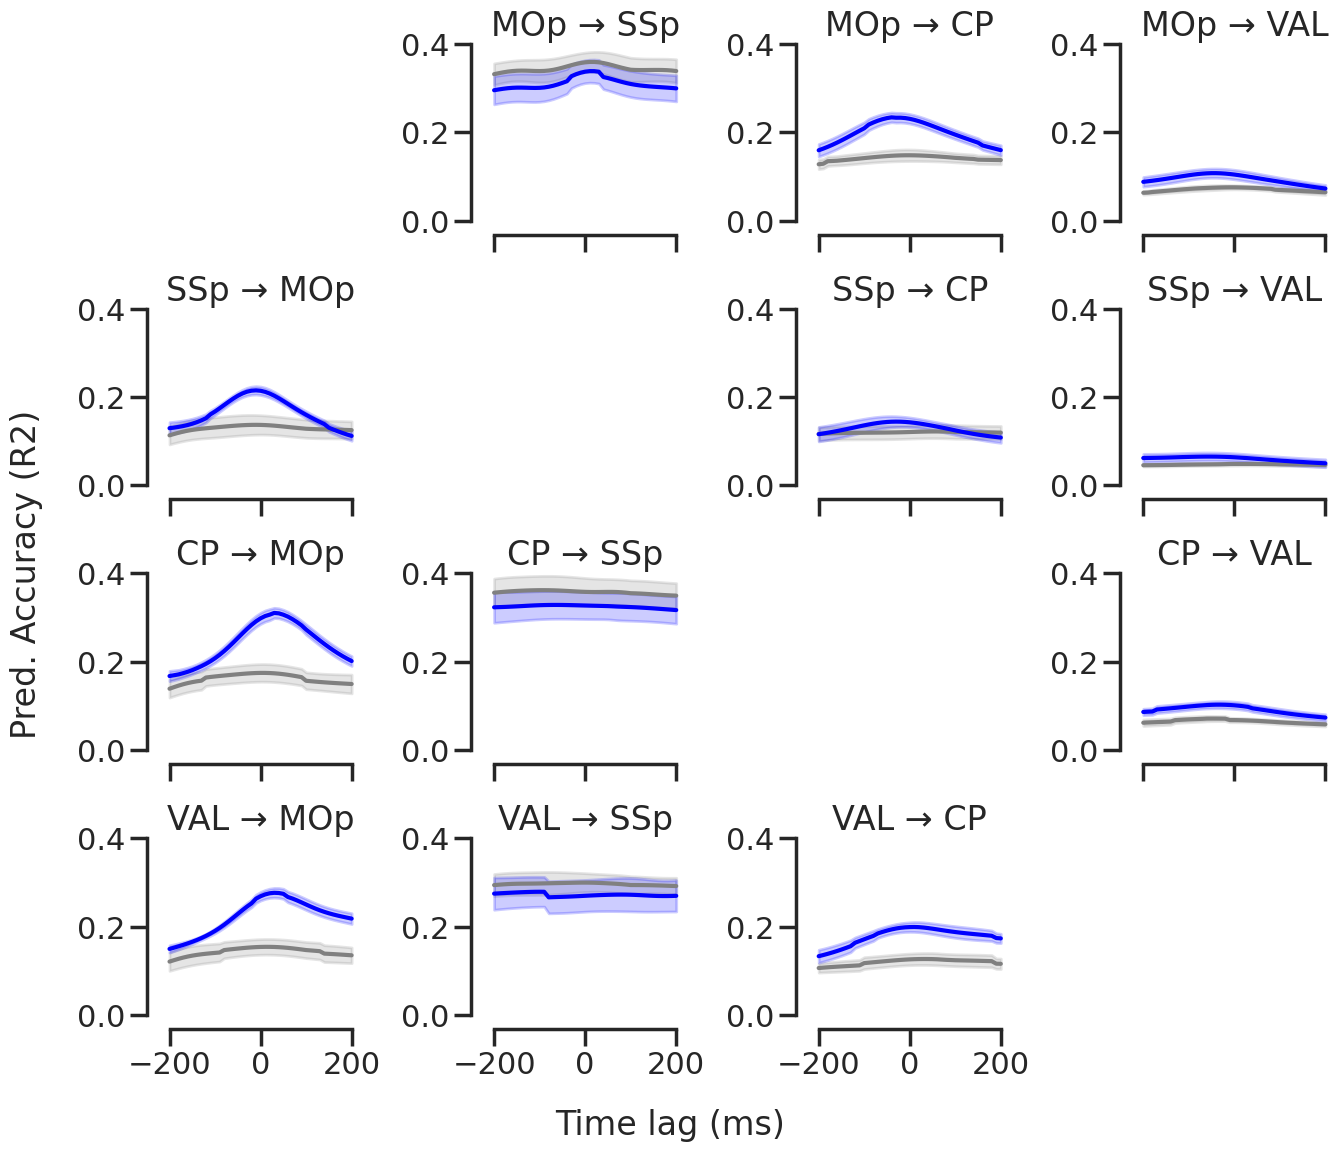

In [112]:
# --- 4x4 grid: overlay R²(lag) for pre (grey) and perturb (blue) ---
with vizutils.apply_plot_style('poster'):
    fig, axes = plt.subplots(len(AREAS), len(AREAS), figsize=(14, 12), sharex=True, sharey=False)

    for i, src in enumerate(AREAS):
        for j, tgt in enumerate(AREAS):
            ax = axes[i, j]
            if src == tgt:
                ax.axis('off')
                continue
            # Get lag-R² curves for pre and perturb
            pre_curve = [results['pre'][lag][src][tgt] for lag in lags]
            post_curve = [results['perturb'][lag][src][tgt] for lag in lags]
            vizutils.shaded_errorbar(ax, lags * 10, pre_curve, color='grey')
            vizutils.shaded_errorbar(ax, lags * 10, post_curve, color='blue')
            # Add source → target as subplot title
            ax.set_title(f'{src} → {tgt}')
            # Remove all axis labels and ticks
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_ylim(0, 0.4)
    # Add global x and y labels
    fig.text(0.5, 0.04, 'Time lag (ms)', ha='center', va='center')
    fig.text(0.04, 0.5, 'Pred. Accuracy (R2)', ha='center', va='center', rotation='vertical')
    plt.tight_layout(rect=[0.06, 0.06, 1, 1])

plt.show()
fig.savefig("rrr_global.pdf", bbox_inches='tight')


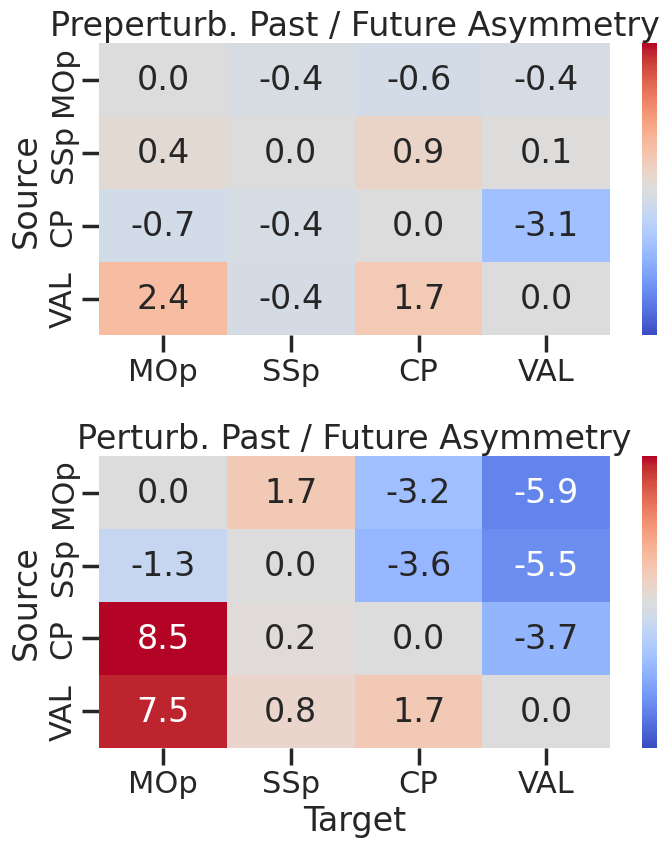

<Figure size 640x480 with 0 Axes>

In [110]:
# --- Heatmaps of normalized right-left AUC for pre and perturb (constrained to lags -10 to 10) ---
auc_pre = np.full((len(AREAS), len(AREAS)), np.nan)
auc_post = np.full((len(AREAS), len(AREAS)), np.nan)

lag_min = -10
lag_max = 10

for i, src in enumerate(AREAS):
    for j, tgt in enumerate(AREAS):
        if src == tgt:
            auc_pre[i, j] = 0.0
            auc_post[i, j] = 0.0
            continue
        pre_curve = np.array([results['pre'][lag][src][tgt][0] for lag in lags], dtype=float)
        post_curve = np.array([results['perturb'][lag][src][tgt][0] for lag in lags], dtype=float)
        lags_arr = np.array(lags)
        mask = (lags_arr >= lag_min) & (lags_arr <= lag_max)
        # Pre
        if not np.all(np.isnan(pre_curve)):
            auc_val = np.nansum(pre_curve[(lags_arr > 0) & mask]) - np.nansum(pre_curve[(lags_arr < 0) & mask])
            total = np.nansum(np.abs(pre_curve[mask]))
            auc_pre[i, j] = 100 * auc_val / (total + 1e-12)
        # Perturb
        if not np.all(np.isnan(post_curve)):
            auc_val = np.nansum(post_curve[(lags_arr > 0) & mask]) - np.nansum(post_curve[(lags_arr < 0) & mask])
            total = np.nansum(np.abs(post_curve[mask]))
            auc_post[i, j] = 100 * auc_val / (total + 1e-12)

vmin = -8
vmax = 8

import seaborn as sns
with vizutils.apply_plot_style('poster'):
    fig, axes = plt.subplots(2, 1, figsize=(8, 9))
    for ax, mat, title in zip(axes, [auc_pre, auc_post], ['Preperturb', 'Perturb']):
        # Format annotations as integers
        annot = np.empty_like(mat, dtype=object)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                annot[i, j] = f'{val:.0f}' if not np.isnan(val) else ''
        hm = sns.heatmap(mat, ax=ax, cmap='coolwarm', vmin=vmin, vmax=vmax, annot=True, fmt='.1f', cbar=True,
                        xticklabels=AREAS, yticklabels=AREAS, square=False, linecolor='gray')
        if hm.collections and hm.collections[0].colorbar:
            hm.collections[0].colorbar.set_ticks([])
            hm.collections[0].colorbar.set_ticklabels([])
            hm.collections[0].colorbar.set_label("")
        ax.set_ylabel('Source')
        ax.set_title(f'{title}. Past / Future Asymmetry')
    ax.set_xlabel('Target')

    plt.tight_layout()
    fig.savefig("rrr_asymmetry.pdf", bbox_inches='tight')
    plt.show()

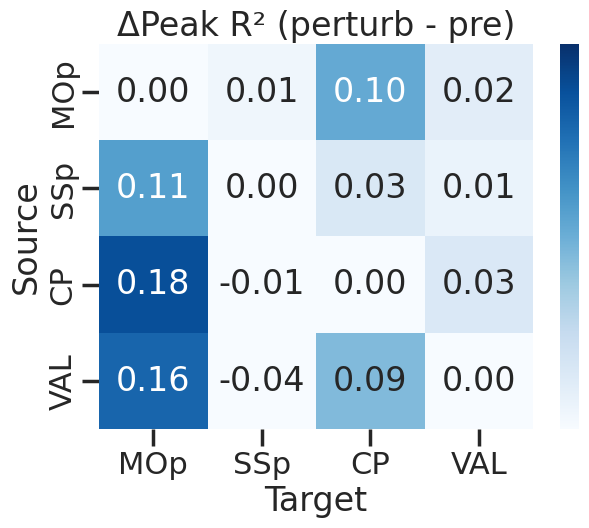

<Figure size 640x480 with 0 Axes>

In [111]:
# --- Heatmap of difference in peak R² (perturb - pre) ---
peak_diff = np.full((len(AREAS), len(AREAS)), np.nan)
for i, src in enumerate(AREAS):
    for j, tgt in enumerate(AREAS):
        if src == tgt:
            peak_diff[i, j] = 0.0
            continue
        pre_curve = np.array([results['pre'][lag][src][tgt][0] for lag in lags], dtype=float)
        post_curve = np.array([results['perturb'][lag][src][tgt][0] for lag in lags], dtype=float)
        if not np.all(np.isnan(pre_curve)) and not np.all(np.isnan(post_curve)):
            peak_pre = np.nanmax(pre_curve)
            peak_post = np.nanmax(post_curve)
            peak_diff[i, j] = 1 * (peak_post - peak_pre)

vmin = 0
vmax = 0.2

import seaborn as sns
with vizutils.apply_plot_style('poster'):
    fig, ax = plt.subplots(figsize=(7, 5))
    annot = np.empty_like(peak_diff, dtype=object)
    for i in range(peak_diff.shape[0]):
        for j in range(peak_diff.shape[1]):
            val = peak_diff[i, j]
            annot[i, j] = f'{val:.0f}' if not np.isnan(val) else ''
    hm = sns.heatmap(peak_diff, ax=ax, cmap='Blues', vmin=vmin, vmax=vmax, annot=True, fmt='.2f', cbar=True,
                    xticklabels=AREAS, yticklabels=AREAS, square=False, linecolor='gray')
    if hm.collections and hm.collections[0].colorbar:
        hm.collections[0].colorbar.set_ticks([])
        hm.collections[0].colorbar.set_ticklabels([])
        hm.collections[0].colorbar.set_label("")
    ax.set_xlabel('Target')
    ax.set_ylabel('Source')
    ax.set_title('ΔPeak R² (perturb - pre)')
    # plt.tight_layout()
    fig.savefig("rrr_diff.pdf", bbox_inches='tight')
    plt.show()

# Run on all sessions

In [25]:
sessions = [
    # 'M061_2025_03_04_10_00', 
    # 'M061_2025_03_05_14_00', 
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    'M063_2025_03_14_15_30', 
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00'
]

In [26]:

# --- Step 1: Load & preprocess all sessions into intermediate dict ---
all_session_processed = {}  # {session: {'td': perturb_td_shuff, 'chance': float} or None}

for sess in tqdm(sessions, desc="Loading sessions"):
    print(f"\n{'='*60}\n{sess}\n{'='*60}")
    try:
        df_tr_s, dstrb_idx_s = dsp.load_and_process_session(sess, data_dir='/data/bnd-data/raw/')
        df_design_s = drop_unperturb_trials_modified(df_tr_s, dstrb_idx_s, thresh_val=-2)

        perturb_td_s = pyal.restrict_to_interval(
            df_design_s, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
        )
        perturb_td_s = dt.add_bhv(perturb_td_s)
        perturb_td_shuff_s = perturb_td_s.sample(frac=1, random_state=42).reset_index(drop=False)

        all_session_processed[sess] = {'td': perturb_td_shuff_s}

    except Exception as e:
        import traceback
        print(f"  ERROR loading {sess}: {e}")
        traceback.print_exc()
        all_session_processed[sess] = None

print(f"\nLoaded {sum(v is not None for v in all_session_processed.values())}/{len(sessions)} sessions successfully.")


Loading sessions:   0%|          | 0/1 [00:00<?, ?it/s]


M063_2025_03_14_15_30
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['VAL_spikes', 'SSp_spikes', 'all_spikes', 'MOp_spikes', 'CP_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (260, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (92, 60000)
Resulting all_spikes ephys data shape is (NxT): (38, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (161, 60000)
Resulting CP_spikes ephys data shape is (NxT): (329, 60000)
Skipped 149 trials
Otsu immobility threshold: 0.8585
Dropped 125 of 337 rows (37.09%).
  threshold = -0.115  |  trials selected by threshold: 130  |  total trials kept: 99


Loading sessions: 100%|██████████| 1/1 [00:54<00:00, 54.72s/it]


Loaded 1/1 sessions successfully.


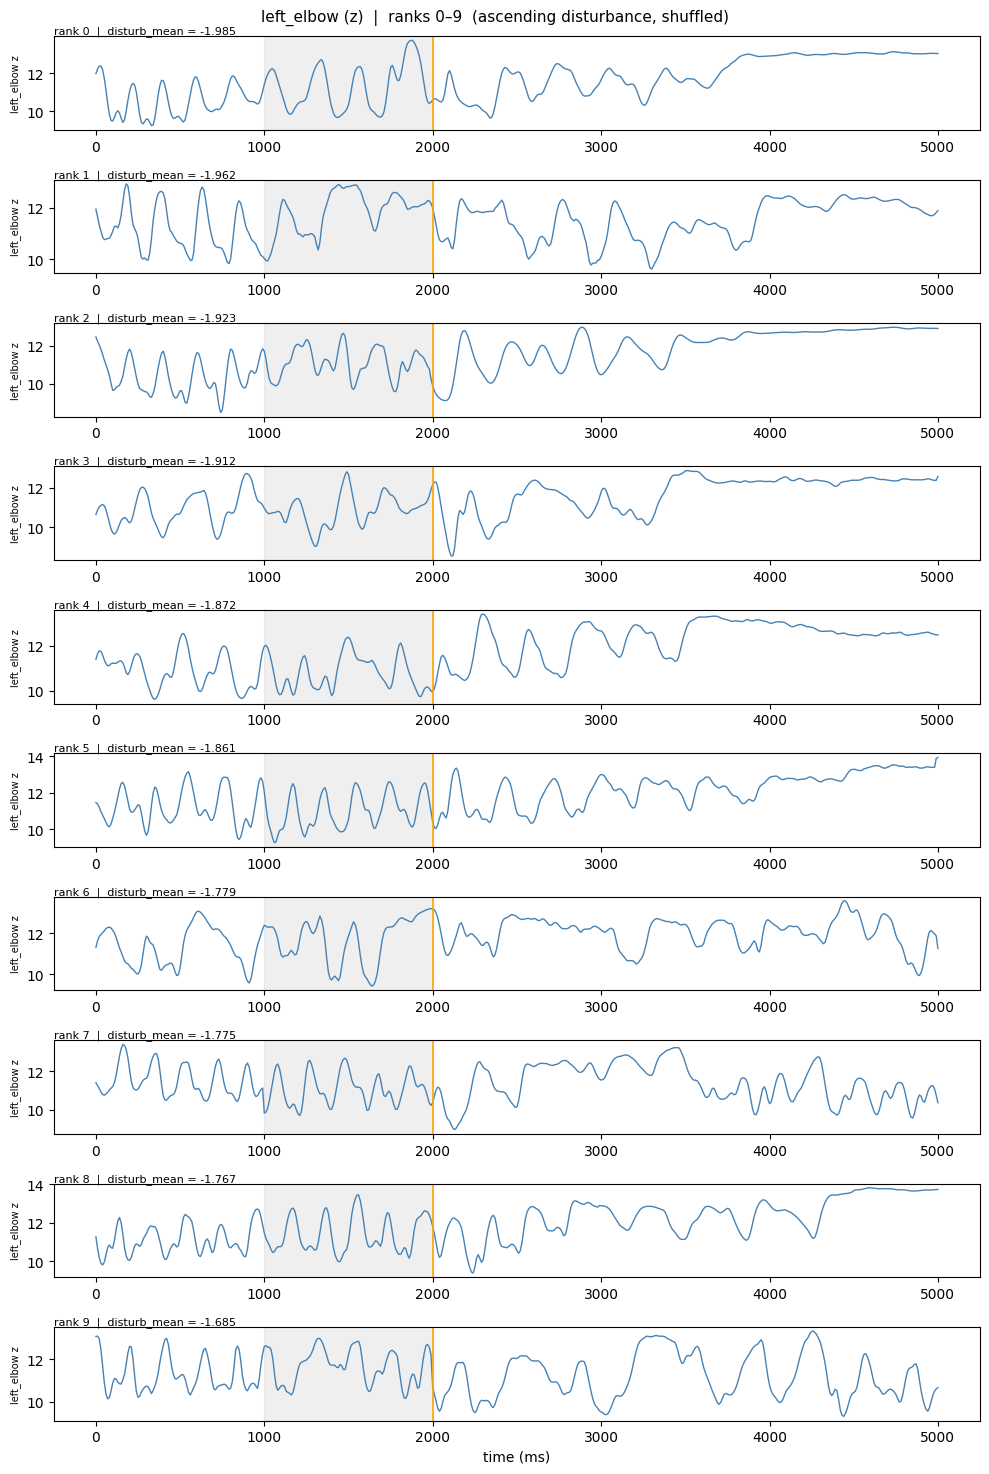

In [28]:
# --- Parameters ---
PAGE = 0
PAGE_SIZE = 10
KEYPOINT = 'left_elbow'   # any name in Params.oscillating_key_points
DIM = 2                  # 0=x, 1=y, 2=z (vertical)
PRE_PERTURB_WINDOW = (100, 200)
# ------------------

kp_idx = list(Params.oscillating_key_points).index(KEYPOINT)
col_idx = kp_idx * 3 + DIM
dim_label = ['x', 'y', 'z'][DIM]

# Sort shuffled trials by increasing disturb_mean
perturb_td_shuff_sorted_s = perturb_td_shuff_s.sort_values('disturb_mean', ascending=True).reset_index(drop=True)

start = PAGE * PAGE_SIZE
end = start + PAGE_SIZE
page_df = perturb_td_shuff_sorted_s.iloc[start:end]

n_rows = len(page_df)
fig, axes = plt.subplots(n_rows, 1, figsize=(10, max(1, n_rows) * 1.5), sharex=False)
if n_rows == 1:
    axes = [axes]

fig.suptitle(
    f"{KEYPOINT} ({dim_label})  |  ranks {start}–{start + n_rows - 1}  "
    f"(ascending disturbance, shuffled)",
    fontsize=11
)

for row, (_, row_data) in enumerate(page_df.iterrows()):
    trace = row_data.bhv[:, col_idx]
    t = np.arange(len(trace)) * 10

    ax = axes[row]
    ax.plot(t, trace, color="steelblue", lw=1)
    ax.axvspan(PRE_PERTURB_WINDOW[0] * 10, PRE_PERTURB_WINDOW[1] * 10, alpha=0.12, color="gray")
    ax.axvline(row_data.idx_sol_on * 10, color="orange", lw=1.2)

    disturb_mean = row_data.disturb_mean
    ax.set_title(
        f"rank {start + row}  |  disturb_mean = {disturb_mean:.3f}",
        fontsize=8, loc="left", pad=2
    )
    ax.set_ylabel(f"{KEYPOINT} {dim_label}", fontsize=7)

    if row == n_rows - 1:
        ax.set_xlabel("time (ms)")

plt.tight_layout()
plt.show()

In [29]:
# --- Step 2: Run reduced-rank regression on selected sessions ---

AREAS = ['MOp', 'SSp', 'CP', 'VAL']
WINDOWS = {'pre': (10, 190), 'perturb': (200, 380)}

rank_dict = {
    'MOp': 30,
    'CP': 30,
    'VAL': 50,
    'SSp': 10
}

lags = np.arange(-20, 21, step=1)

# ------------------------------------------------------------------
# Choose which loaded sessions to run
# If None: run all successfully loaded sessions
# Otherwise: run only the listed sessions
# ------------------------------------------------------------------
sessions_to_run = [
    # 'M061_2025_03_04_10_00', 
    # 'M061_2025_03_05_14_00', 
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    'M063_2025_03_14_15_30', 
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00'
]

# Per-session area exclusions
session_area_exclusions = {
    # 'M062_2025_03_20_14_00': ['VAL'],
    # 'M062_2025_03_21_14_00': ['SSp', 'CP'],
}

# ------------------------------------------------------------------
# Resolve run list
# ------------------------------------------------------------------
if sessions_to_run is None:
    run_sessions = [
        sess for sess, sess_data in all_session_processed.items()
        if sess_data is not None
    ]
else:
    run_sessions = []
    for sess in sessions_to_run:
        if sess not in all_session_processed:
            print(f"WARNING: {sess} not found in all_session_processed, skipping.")
            continue
        if all_session_processed[sess] is None:
            print(f"WARNING: {sess} failed preprocessing/loading, skipping.")
            continue
        run_sessions.append(sess)

print(f"\nRunning RRR on {len(run_sessions)} sessions:")
for sess in run_sessions:
    print(f"  - {sess}")
    
# results_all[sess][window_label][lag][src][tgt] = r2
results_all = {}

for sess in tqdm(run_sessions, desc="Running RRR across selected sessions"):
    print(f"\n{'='*60}\nSession: {sess}\n{'='*60}")

    sess_data = all_session_processed[sess]
    perturb_td_shuff = sess_data['td']

    excluded_areas = set(session_area_exclusions.get(sess, []))

    if excluded_areas:
        print(f"  Excluding areas for {sess}: {sorted(excluded_areas)}")

    active_areas = [a for a in AREAS if a not in excluded_areas]
    if len(active_areas) == 0:
        print(f"  Skipping {sess}: all areas excluded.")
        results_all[sess] = None
        continue

    results_all[sess] = {label: {} for label in WINDOWS}

    for label, window in WINDOWS.items():
        print(f"\n{'-'*40}\nWindow: {label} {window}\n{'-'*40}")

        for lag in tqdm(lags, desc=f"{sess} | {label}", leave=False):
            results_all[sess][label][lag] = {}

            for src in AREAS:
                results_all[sess][label][lag][src] = {}

                for tgt in AREAS:
                    if src == tgt or src in excluded_areas or tgt in excluded_areas:
                        results_all[sess][label][lag][src][tgt] = np.nan
                        continue

                    sig_x = f'{src}_rates_pca'
                    sig_y = f'{tgt}_rates_pca'

                    if sig_x not in perturb_td_shuff.columns or sig_y not in perturb_td_shuff.columns:
                        print(f"  {src} → {tgt}: missing column in {sess}, skipping")
                        results_all[sess][label][lag][src][tgt] = np.nan
                        continue

                    try:
                        r2, opt_rank = subspaces.windowed_cross_val_semedo_rrr_td(
                            perturb_td_shuff,
                            sig_x,
                            sig_y,
                            target_rank=rank_dict[tgt],
                            window=window,
                            fit_rank=True,
                            origin_rank=rank_dict[src],
                            lag=lag
                        )
                        results_all[sess][label][lag][src][tgt] = r2

                        # Optional:
                        # results_all[sess][label][lag][src][tgt] = {
                        #     'r2': r2,
                        #     'opt_rank': opt_rank
                        # }

                    except Exception as e:
                        print(f"  ERROR in {sess} | {label} | lag={lag} | {src}→{tgt}: {e}")
                        results_all[sess][label][lag][src][tgt] = np.nan


Running RRR on 1 sessions:
  - M063_2025_03_14_15_30


Running RRR across selected sessions:   0%|          | 0/1 [00:00<?, ?it/s]


Session: M063_2025_03_14_15_30

----------------------------------------
Window: pre (10, 190)
----------------------------------------



----------------------------------------
Window: perturb (200, 380)
----------------------------------------


Running RRR across selected sessions: 100%|██████████| 1/1 [09:03<00:00, 543.45s/it]


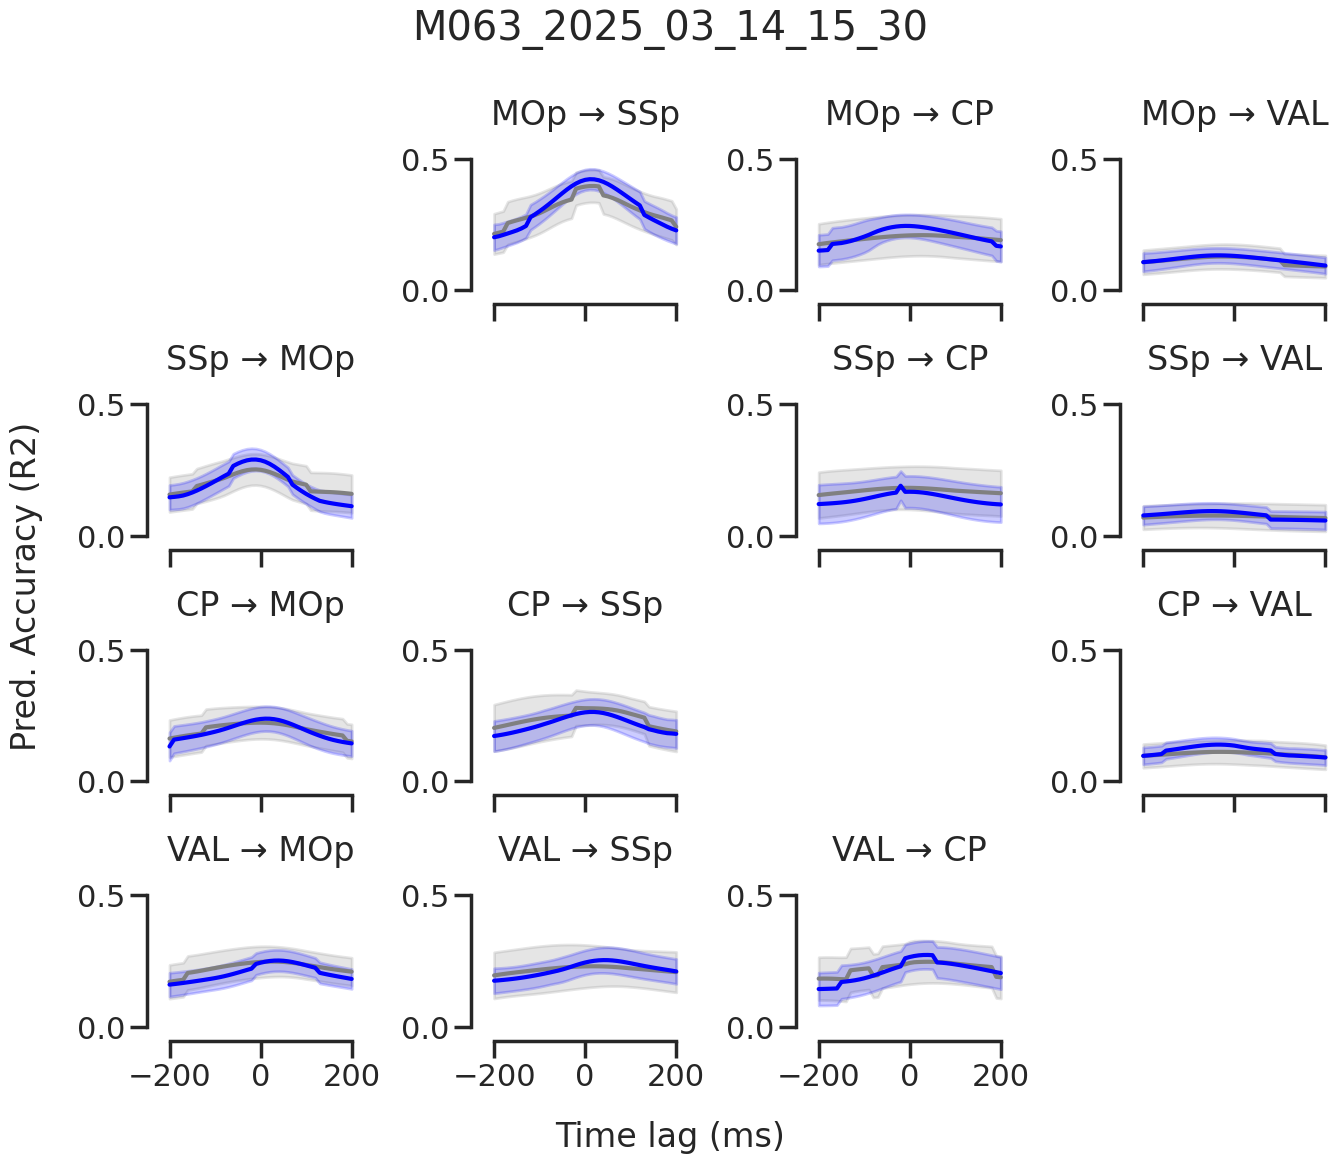

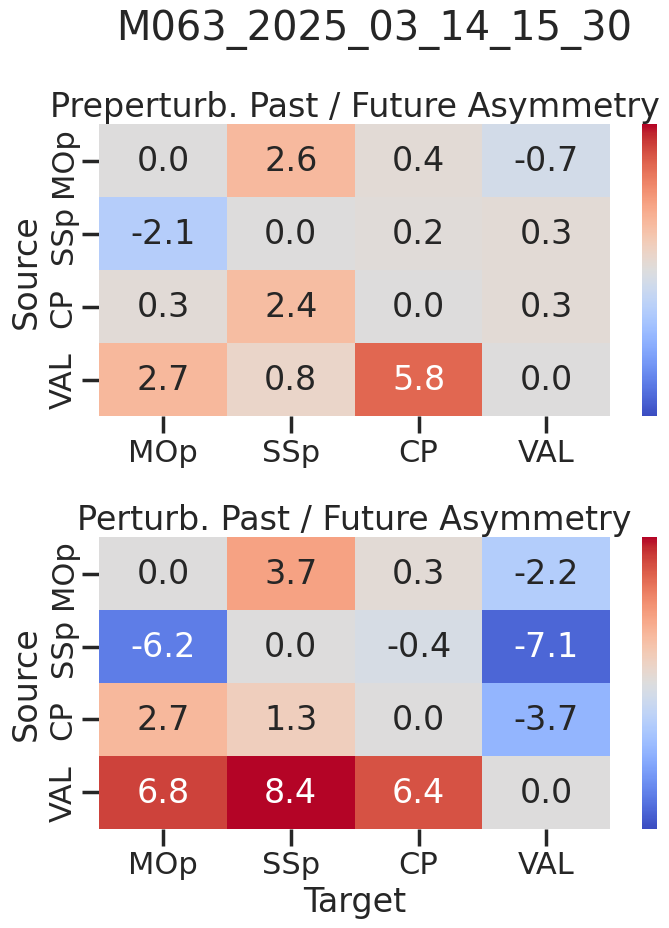

<Figure size 640x480 with 0 Axes>

In [30]:
for session in  results_all.keys():   
    results = results_all[session]

    # --- 4x4 grid: overlay R²(lag) for pre (grey) and perturb (blue) ---
    with vizutils.apply_plot_style('poster'):
        fig, axes = plt.subplots(len(AREAS), len(AREAS), figsize=(14, 12), sharex=True, sharey=False)

        for i, src in enumerate(AREAS):
            for j, tgt in enumerate(AREAS):
                ax = axes[i, j]
                if src == tgt:
                    ax.axis('off')
                    continue
                # Get lag-R² curves for pre and perturb
                pre_curve = [results['pre'][lag][src][tgt] for lag in lags]
                post_curve = [results['perturb'][lag][src][tgt] for lag in lags]
                vizutils.shaded_errorbar(ax, lags * 10, pre_curve, color='grey')
                vizutils.shaded_errorbar(ax, lags * 10, post_curve, color='blue')
                # Add source → target as subplot title
                ax.set_title(f'{src} → {tgt}')
                # Remove all axis labels and ticks
                ax.set_xlabel("")
                ax.set_ylabel("")
                ax.set_ylim(0, 0.6)
        # Add global x and y labels
        fig.text(0.5, 0.04, 'Time lag (ms)', ha='center', va='center')
        fig.text(0.04, 0.5, 'Pred. Accuracy (R2)', ha='center', va='center', rotation='vertical')
        plt.suptitle(session)
        plt.tight_layout(rect=[0.06, 0.06, 1, 1])

    plt.show()
    # --- Heatmaps of normalized right-left AUC for pre and perturb (constrained to lags -10 to 10) ---
    auc_pre = np.full((len(AREAS), len(AREAS)), np.nan)
    auc_post = np.full((len(AREAS), len(AREAS)), np.nan)

    lag_min = -10
    lag_max = 10

    for i, src in enumerate(AREAS):
        for j, tgt in enumerate(AREAS):
            if src == tgt:
                auc_pre[i, j] = 0.0
                auc_post[i, j] = 0.0
                continue
            pre_curve = np.array([results['pre'][lag][src][tgt][0] for lag in lags], dtype=float)
            post_curve = np.array([results['perturb'][lag][src][tgt][0] for lag in lags], dtype=float)
            lags_arr = np.array(lags)
            mask = (lags_arr >= lag_min) & (lags_arr <= lag_max)
            # Pre
            if not np.all(np.isnan(pre_curve)):
                auc_val = np.nansum(pre_curve[(lags_arr > 0) & mask]) - np.nansum(pre_curve[(lags_arr < 0) & mask])
                total = np.nansum(np.abs(pre_curve[mask]))
                auc_pre[i, j] = 100 * auc_val / (total + 1e-12)
            # Perturb
            if not np.all(np.isnan(post_curve)):
                auc_val = np.nansum(post_curve[(lags_arr > 0) & mask]) - np.nansum(post_curve[(lags_arr < 0) & mask])
                total = np.nansum(np.abs(post_curve[mask]))
                auc_post[i, j] = 100 * auc_val / (total + 1e-12)

    vmin = -8
    vmax = 8

    import seaborn as sns
    with vizutils.apply_plot_style('poster'):
        fig, axes = plt.subplots(2, 1, figsize=(8, 9))
        for ax, mat, title in zip(axes, [auc_pre, auc_post], ['Preperturb', 'Perturb']):
            # Format annotations as integers
            annot = np.empty_like(mat, dtype=object)
            for i in range(mat.shape[0]):
                for j in range(mat.shape[1]):
                    val = mat[i, j]
                    annot[i, j] = f'{val:.0f}' if not np.isnan(val) else ''
            hm = sns.heatmap(mat, ax=ax, cmap='coolwarm', vmin=vmin, vmax=vmax, annot=True, fmt='.1f', cbar=True,
                            xticklabels=AREAS, yticklabels=AREAS, square=False, linecolor='gray')
            if hm.collections and hm.collections[0].colorbar:
                hm.collections[0].colorbar.set_ticks([])
                hm.collections[0].colorbar.set_ticklabels([])
                hm.collections[0].colorbar.set_label("")
            ax.set_ylabel('Source')
            ax.set_title(f'{title}. Past / Future Asymmetry')
        ax.set_xlabel('Target')

        plt.tight_layout()
        plt.suptitle(session, y=1.05)

        # fig.savefig("rrr_asymmetry.pdf", bbox_inches='tight')
        plt.show()


In [35]:
with open("all_sessions_rrr.pkl", "wb") as f:
    pickle.dump(results_all, f)

# Load sessions

In [5]:
with open("all_sessions_rrr.pkl", "rb") as f:
    rrr_all_sessions = pickle.load(f)

In [6]:
rrr_all_sessions.keys()

dict_keys(['M063_2025_03_14_15_30', 'M063_2025_03_13_14_00', 'M061_2025_03_06_14_00', 'M078_2025_08_06_15_00', 'M061_2025_03_04_10_00', 'M061_2025_03_05_14_00'])

<Figure size 640x480 with 0 Axes>

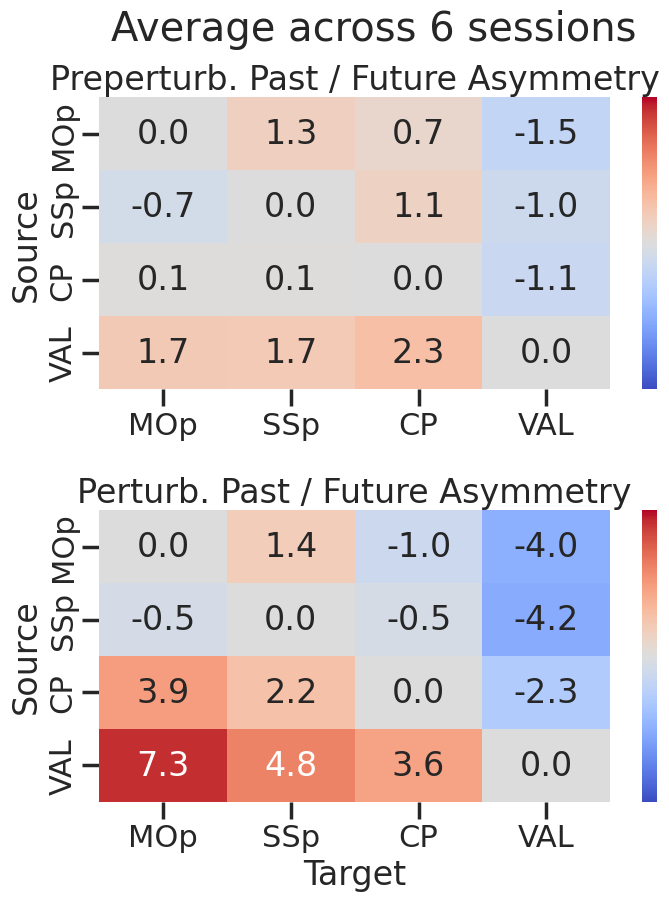

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters ---
lag_min = -10
lag_max = 10
vmin = -8
vmax = 8

lags = np.arange(-20, 21, step=1)
lags_arr = np.array(lags)
mask = (lags_arr >= lag_min) & (lags_arr <= lag_max)

n_areas = len(Params.areas)

# Store per-session matrices
all_auc_pre = []
all_auc_post = []

for session, results in rrr_all_sessions.items():
    auc_pre = np.full((n_areas, n_areas), np.nan)
    auc_post = np.full((n_areas, n_areas), np.nan)

    for i, src in enumerate(Params.areas):
        for j, tgt in enumerate(Params.areas):
            if src == tgt:
                auc_pre[i, j] = 0.0
                auc_post[i, j] = 0.0
                continue

            pre_curve = np.array(
                [results['pre'][lag][src][tgt][0] for lag in lags],
                dtype=float
            )
            post_curve = np.array(
                [results['perturb'][lag][src][tgt][0] for lag in lags],
                dtype=float
            )

            # Pre
            if not np.all(np.isnan(pre_curve)):
                auc_val = (
                    np.nansum(pre_curve[(lags_arr > 0) & mask]) -
                    np.nansum(pre_curve[(lags_arr < 0) & mask])
                )
                total = np.nansum(np.abs(pre_curve[mask]))
                auc_pre[i, j] = 100 * auc_val / (total + 1e-12)

            # Perturb
            if not np.all(np.isnan(post_curve)):
                auc_val = (
                    np.nansum(post_curve[(lags_arr > 0) & mask]) -
                    np.nansum(post_curve[(lags_arr < 0) & mask])
                )
                total = np.nansum(np.abs(post_curve[mask]))
                auc_post[i, j] = 100 * auc_val / (total + 1e-12)

    all_auc_pre.append(auc_pre)
    all_auc_post.append(auc_post)

# Stack across sessions: shape = (n_sessions, n_areas, n_areas)
all_auc_pre = np.stack(all_auc_pre, axis=0)
all_auc_post = np.stack(all_auc_post, axis=0)

# Average across sessions
mean_auc_pre = np.nanmean(all_auc_pre, axis=0)
mean_auc_post = np.nanmean(all_auc_post, axis=0)

# Optional: SEM across sessions
sem_auc_pre = np.nanstd(all_auc_pre, axis=0) / np.sqrt(np.sum(~np.isnan(all_auc_pre), axis=0))
sem_auc_post = np.nanstd(all_auc_post, axis=0) / np.sqrt(np.sum(~np.isnan(all_auc_post), axis=0))

with vizutils.apply_plot_style('poster'):
    fig, axes = plt.subplots(2, 1, figsize=(8, 9))

    for ax, mat, title in zip(
        axes,
        [mean_auc_pre, mean_auc_post],
        ['Preperturb', 'Perturb']
    ):
        annot = np.empty_like(mat, dtype=object)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                annot[i, j] = f'{val:.0f}' if not np.isnan(val) else ''

        hm = sns.heatmap(
            mat,
            ax=ax,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt='.1f',
            cbar=True,
            xticklabels=Params.areas,
            yticklabels=Params.areas,
            square=False,
            linecolor='gray'
        )

        if hm.collections and hm.collections[0].colorbar:
            hm.collections[0].colorbar.set_ticks([])
            hm.collections[0].colorbar.set_ticklabels([])
            hm.collections[0].colorbar.set_label("")

        ax.set_ylabel('Source')
        ax.set_title(f'{title}. Past / Future Asymmetry')

    axes[-1].set_xlabel('Target')
    plt.tight_layout()
    plt.suptitle(f'Average across {len(rrr_all_sessions)} sessions', y=1.02)
    plt.show()

In [14]:
all_auc_pre[0]

array([[ 0.        ,  2.58502003,  0.36516089, -0.67374869],
       [-2.13166004,  0.        ,  0.21257896,  0.31502624],
       [ 0.29137427,  2.38586126,  0.        ,  0.32378518],
       [ 2.68331821,  0.8488581 ,  5.75573687,  0.        ]])

In [15]:
all_auc_post[0]

array([[ 0.        ,  3.65887364,  0.32693262, -2.24682683],
       [-6.18674357,  0.        , -0.39517597, -7.0607041 ],
       [ 2.66725054,  1.3452552 ,  0.        , -3.68862258],
       [ 6.84402595,  8.43114192,  6.41453818,  0.        ]])

<Figure size 640x480 with 0 Axes>

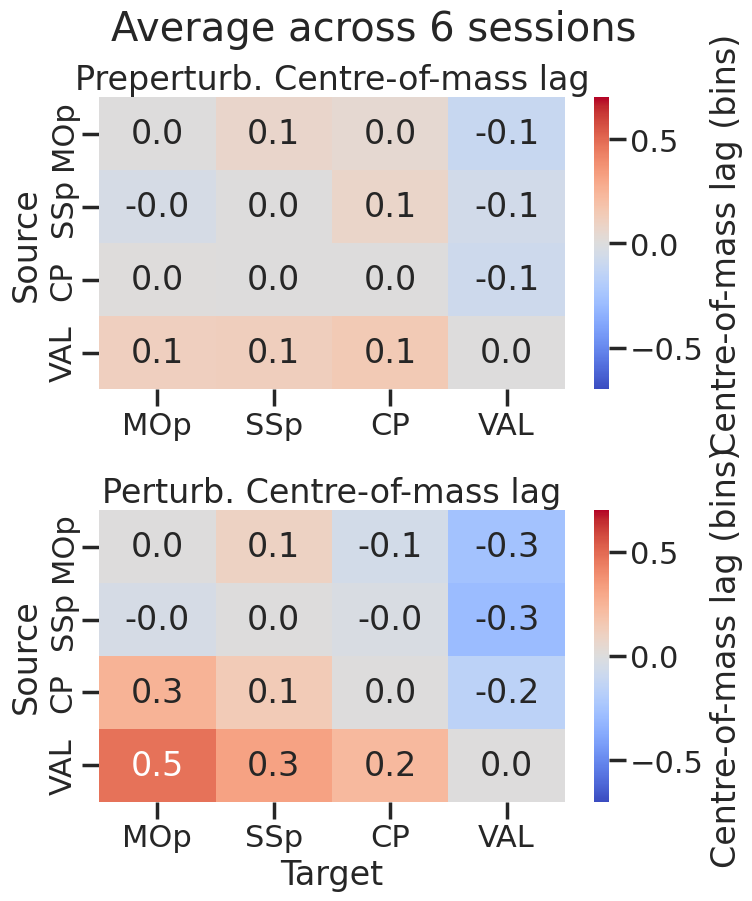

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters ---
lag_min = -10
lag_max = 10
vmin = -0.7   # adjust as needed
vmax = 0.7

lags = np.arange(-20, 21, step=1)
lags_arr = np.array(lags)
mask = (lags_arr >= lag_min) & (lags_arr <= lag_max)

n_areas = len(Params.areas)

# Choose weighting scheme:
# 1) weights = curve_win                 # use raw values (only sensible if non-negative)
# 2) weights = np.abs(curve_win)         # use magnitude
# 3) weights = np.clip(curve_win, 0, None)  # use positive part only
use_abs_weights = True
weights = 20  
# Store per-session matrices
all_com_pre = []
all_com_post = []

for session, results in rrr_all_sessions.items():
    com_pre = np.full((n_areas, n_areas), np.nan)
    com_post = np.full((n_areas, n_areas), np.nan)

    for i, src in enumerate(Params.areas):
        for j, tgt in enumerate(Params.areas):
            if src == tgt:
                com_pre[i, j] = 0.0
                com_post[i, j] = 0.0
                continue

            pre_curve = np.array(
                [results['pre'][lag][src][tgt][0] for lag in lags],
                dtype=float
            )
            post_curve = np.array(
                [results['perturb'][lag][src][tgt][0] for lag in lags],
                dtype=float
            )

            # --- Pre ---
            if not np.all(np.isnan(pre_curve)):
                curve_win = pre_curve[mask]
                lags_win = lags_arr[mask]

                if use_abs_weights:
                    weights = np.abs(curve_win)
                else:
                    weights = curve_win

                valid = ~np.isnan(weights)
                weights = weights[valid]
                lags_valid = lags_win[valid]

                total_weight = np.sum(weights)
                if total_weight > 0:
                    com_pre[i, j] = np.sum(lags_valid * weights) / total_weight

            # --- Perturb ---
            if not np.all(np.isnan(post_curve)):
                curve_win = post_curve[mask]
                lags_win = lags_arr[mask]

                if use_abs_weights:
                    weights = np.abs(curve_win)
                else:
                    weights = curve_win

                valid = ~np.isnan(weights)
                weights = weights[valid]
                lags_valid = lags_win[valid]

                total_weight = np.sum(weights)
                if total_weight > 0:
                    com_post[i, j] = np.sum(lags_valid * weights) / total_weight

    all_com_pre.append(com_pre)
    all_com_post.append(com_post)

# Stack across sessions: shape = (n_sessions, n_areas, n_areas)
all_com_pre = np.stack(all_com_pre, axis=0)
all_com_post = np.stack(all_com_post, axis=0)

# Average across sessions
mean_com_pre = np.nanmean(all_com_pre, axis=0)
mean_com_post = np.nanmean(all_com_post, axis=0)

# Optional: SEM across sessions
sem_com_pre = np.nanstd(all_com_pre, axis=0) / np.sqrt(np.sum(~np.isnan(all_com_pre), axis=0))
sem_com_post = np.nanstd(all_com_post, axis=0) / np.sqrt(np.sum(~np.isnan(all_com_post), axis=0))

with vizutils.apply_plot_style('poster'):
    fig, axes = plt.subplots(2, 1, figsize=(8, 9))

    for ax, mat, title in zip(
        axes,
        [mean_com_pre, mean_com_post],
        ['Preperturb', 'Perturb']
    ):
        hm = sns.heatmap(
            mat,
            ax=ax,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt='.1f',
            cbar=True,
            xticklabels=Params.areas,
            yticklabels=Params.areas,
            square=False,
            linecolor='gray'
        )

        cbar = hm.collections[0].colorbar
        cbar.set_label('Centre-of-mass lag (bins)')

        ax.set_ylabel('Source')
        ax.set_title(f'{title}. Centre-of-mass lag')

    axes[-1].set_xlabel('Target')
    plt.tight_layout()
    plt.suptitle(f'Average across {len(rrr_all_sessions)} sessions', y=1.02)
    plt.show()